In [1]:
# Import necessary libraries
import os, mne, re, csv, numpy as np, matplotlib.pyplot as plt
from glob import glob
from mne.channels import make_standard_montage
from mne.time_frequency import tfr_morlet
from eeg_function import drop_trials, single_trial_normalisation
# Set the derivatives directory path
root_derivatives = 'C:/Users/mfbpe/Desktop/DATA/2025_Valuation/derivatives/'

# Change the current working directory to the derivatives directory
os.chdir(root_derivatives)

all_files_path = sorted(glob(f"*raw.fif"), key=len)

In [17]:

event_id_stim = { 
    'stim/motiv/extr':11,'stim/motiv/hard':12,'stim/motiv/easy':13,'stim/amotiv/extr':14,'stim/amotiv/hard':15,'stim/amotiv/easy':16
}


part = all_files_path[0]
raw = mne.io.read_raw_fif(part, preload=True)

events = mne.find_events(raw, shortest_event=1)            

epochs= mne.Epochs(raw, events,baseline = (-.3, -.1), event_id=event_id_stim, picks='eeg',
        tmin=-2, tmax=3,preload=True, detrend=None, on_missing='ignore')


sphere = mne.make_sphere_model('auto', 'auto', epochs.info)
src = mne.setup_volume_source_space(sphere=sphere)
forward = mne.make_forward_solution(epochs.info, trans=None, src=src, bem=sphere)


epochs.set_eeg_reference('REST', forward=forward)
chs_index = [i for i,x in enumerate(epochs.info['ch_names']) if x in ['FCz','Pz']]
epochs_comb = mne.channels.combine_channels(epochs, dict(Avg=chs_index)) # reject artifact on the combination of channels of interest
_, list_ti, _, _, _ = drop_trials(epochs_comb, do_mean=1, do_peak=1, do_slope=1, T1=-.3,T2=.5, chs='all')  
epochs_cleaned = epochs.copy().drop(list_ti==0)


Opening raw data file sub-1_raw.fif...
    Range : 0 ... 1927679 =      0.000 ...  3764.998 secs
Ready.
Reading 0 ... 1927679  =      0.000 ...  3764.998 secs...
Finding events on: Status
2016 events found on stim channel Status
Event IDs: [ 1  2  3  4  5  6 11 12 13 14 15 16 21 22 23 24 25 26 31 32 33 34 35 36
 41 42 43 44 45 46 51 52 53 54 55 56]
Not setting metadata
336 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 336 events and 2561 original time points ...
0 bad epochs dropped
Fitted sphere radius:         95.0 mm
Origin head coordinates:      -0.0 -0.0 40.1 mm
Origin device coordinates:    -0.0 -0.0 40.1 mm

Equiv. model fitting -> RV = 0.00348862 %%
mu1 = 0.944723    lambda1 = 0.137154
mu2 = 0.66746    lambda2 = 0.683797
mu3 = -0.267046    lambda3 = -0.0105814
Set up EEG sphere model with scalp radius    95.0 mm

Sphere                : origin at (-0.0 -0.0 40.1) mm
              radius  : 85.5 mm


# Time-frequency analysis (Morlet wavelet transform)

![title](Difficulty.png)

In [18]:
freqs = np.logspace(np.log10(2), np.log10(30), num=80)
freqs

array([ 2.        ,  2.06974683,  2.14192598,  2.21662225,  2.29392345,
        2.37392039,  2.45670711,  2.54238088,  2.63104239,  2.72279582,
        2.81774902,  2.91601355,  3.01770491,  3.12294259,  3.23185027,
        3.34455593,  3.46119202,  3.58189561,  3.70680855,  3.83607763,
        3.96985476,  4.10829716,  4.25156752,  4.3998342 ,  4.55327146,
        4.71205959,  4.87638521,  5.04644142,  5.22242807,  5.40455198,
        5.59302718,  5.78807514,  5.9899251 ,  6.19881425,  6.41498808,
        6.63870064,  6.87021481,  7.10980267,  7.35774578,  7.61433552,
        7.87987341,  8.15467152,  8.43905278,  8.73335138,  9.03791318,
        9.3530961 ,  9.67927051, 10.01681975, 10.36614047, 10.72764321,
       11.10175278, 11.48890883, 11.88956634, 12.30419614, 12.73328549,
       13.17733866, 13.63687749, 14.112442  , 14.60459107, 15.11390305,
       15.64097649, 16.18643078, 16.75090693, 17.33506828, 17.93960134,
       18.56521653, 19.21264906, 19.88265978, 20.57603606, 21.29

![title](morlet.png)

In [19]:
n_cycles = np.logspace(np.log10(4), np.log10(14), 80)
n_cycles

array([ 4.        ,  4.06393664,  4.12889526,  4.19489218,  4.26194401,
        4.33006761,  4.39928011,  4.46959891,  4.54104169,  4.61362643,
        4.68737138,  4.76229508,  4.83841637,  4.91575439,  4.9943286 ,
        5.07415875,  5.15526492,  5.2376675 ,  5.32138722,  5.40644513,
        5.49286261,  5.58066141,  5.6698636 ,  5.76049161,  5.85256823,
        5.94611663,  6.04116031,  6.13772319,  6.23582954,  6.33550404,
        6.43677175,  6.53965815,  6.64418909,  6.75039088,  6.85829021,
        6.96791422,  7.07929048,  7.192447  ,  7.30741223,  7.42421508,
        7.54288493,  7.66345161,  7.78594545,  7.91039725,  8.03683831,
        8.16530043,  8.2958159 ,  8.42841756,  8.56313874,  8.70001332,
        8.83907573,  8.98036094,  9.12390447,  9.26974242,  9.41791148,
        9.56844888,  9.72139251,  9.87678081, 10.03465286, 10.19504836,
       10.35800765, 10.52357171, 10.69178217, 10.86268133, 11.03631218,
       11.21271836, 11.39194426, 11.57403492, 11.75903616, 11.94

In [20]:

power = epochs_cleaned.compute_tfr('morlet', freqs=freqs, n_cycles=n_cycles, use_fft=True, average=False, return_itc=False, decim=10, n_jobs=-1)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  62 out of  64 | elapsed:   21.2s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:   21.4s finished


In [21]:
power

Data type,Power Estimates
Data source,Epochs
Number of epochs,271
Dims,"epoch, channel, freq, time"
Estimation method,morlet
Number of channels,64
Number of timepoints,257
Number of frequency bins,80
Frequency range,2.00 – 30.00 Hz


No baseline correction applied


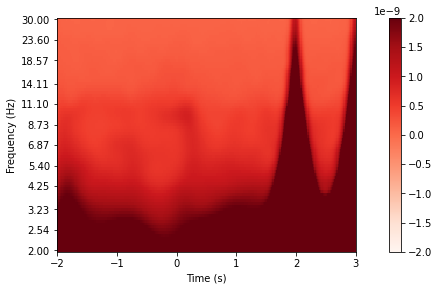

[<Figure size 432x288 with 2 Axes>]

In [22]:
power.average().plot(picks="FCz", vlim=(-2e-9, 2e-9))

In [24]:
power.crop(-1.5, 1.5)

Data type,Power Estimates
Data source,Epochs
Number of epochs,271
Dims,"epoch, channel, freq, time"
Estimation method,morlet
Number of channels,64
Number of timepoints,155
Number of frequency bins,80
Frequency range,2.00 – 30.00 Hz


No baseline correction applied


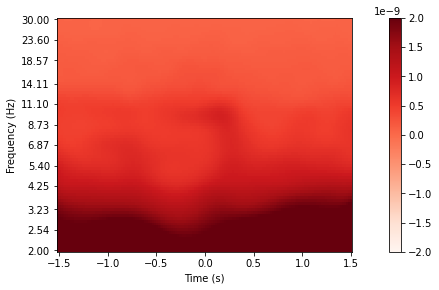

[<Figure size 432x288 with 2 Axes>]

In [25]:
power.average().plot(picks="FCz", vlim=(-2e-9, 2e-9))

Applying baseline correction (mode: zlogratio)


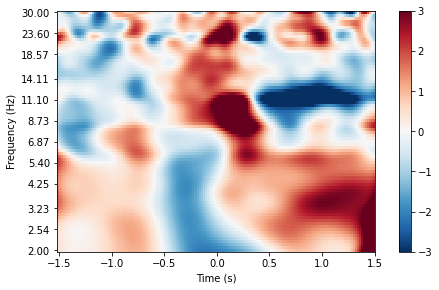

[<Figure size 432x288 with 2 Axes>]

In [29]:
power.average().plot(baseline=(-1.5, -.1), mode='zlogratio', vlim=(-3,3), picks="FCz") # different baselines 'logratio', 'ratio', 'zscore', 'mean', 'percent', and 'zlogratio'

In [31]:

power_w_baseline = single_trial_normalisation(power, tmin_baseline = -1.5, tmax_baseline = -.1, tmin_power = -1.5, tmax_power = 1.5) #use the method of Grandchamp & Delorme, baseline is classical baseline, power is the period of interest from baseline to a bit more than the expected signal


No baseline correction applied


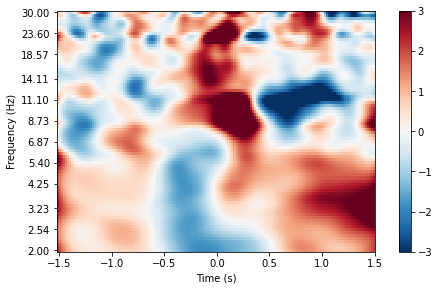

[<Figure size 432x288 with 2 Axes>]

In [33]:
power.average().plot(picks="FCz", vlim=(-3, 3))

In [38]:
power.plot()

NotImplementedError: Cannot call plot() from EpochsTFR with multiple epochs; please subselect a single epoch before plotting.

No baseline correction applied


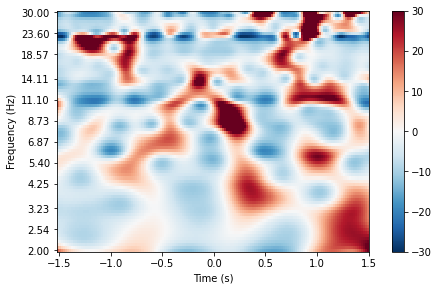

No baseline correction applied


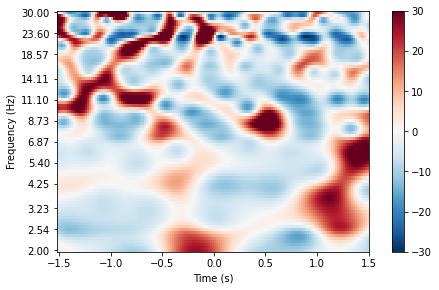

[<Figure size 432x288 with 2 Axes>]

In [40]:
power[0].plot(picks="FCz", vlim=(-30, 30))
power[1].plot(picks="FCz", vlim=(-30, 30))

In [41]:
%%capture 

event_id_stim = { 
    'stim/motiv/extr':11,'stim/motiv/hard':12,'stim/motiv/easy':13,'stim/amotiv/extr':14,'stim/amotiv/hard':15,'stim/amotiv/easy':16
}

for i,part in enumerate(all_files_path[:20]): #only first 20 participants for the sake of practice

    raw = mne.io.read_raw_fif(part, preload=True)
    
    events = mne.find_events(raw, shortest_event=1)            

    epochs= mne.Epochs(raw, events,baseline = (-.3, -.1), event_id=event_id_stim, picks='eeg',
            tmin=-2, tmax=3,preload=True, detrend=None, on_missing='ignore')

    if i==0:  
        sphere = mne.make_sphere_model('auto', 'auto', epochs.info)
        src = mne.setup_volume_source_space(sphere=sphere)
        forward = mne.make_forward_solution(epochs.info, trans=None, src=src, bem=sphere)

    epochs.set_eeg_reference('REST', forward=forward)
    

    chs_index = [i for i,x in enumerate(epochs.info['ch_names']) if x in ['FCz','Fz']]
            # Combine channels into one average

    epochs_comb = mne.channels.combine_channels(epochs, dict(Avg=chs_index))
    _,list_ti,_,_,_ = drop_trials(epochs_comb, do_mean=1, do_peak=1, do_slope=1, T1=-.3,T2=.5, chs='all')  
    
    epochs.drop(list_ti==0)

    # Time-frequency analysis (Morlet wavelet transform)
    freqs = np.logspace(np.log10(2), np.log10(30), num=80)
    n_cycles = np.logspace(np.log10(4), np.log10(14), 80)
    power = epochs.compute_tfr('morlet', freqs=freqs, n_cycles=n_cycles, use_fft=True, average=False, return_itc=False, decim=10, n_jobs=-1)

    power = single_trial_normalisation(power, tmin_baseline = -1.5, tmax_baseline = -.1, tmin_power = -1.5, tmax_power = 1.5) #use the method of Grandchamp & Delorme, baseline is classical baseline, power is the period of interest from baseline to a bit more than the expected signal

    # Save the power data (time-frequency representation)
    power.crop(-.3,1.5)

    conditions = ['motiv/extr', 'motiv/hard', 'motiv/easy', 'amotiv/extr', 'amotiv/hard', 'amotiv/easy']
    for cond in conditions:
        power[cond].average().save(part.split('raw.fif')[0] + cond.replace("/", "-") + '_tfr.h5', overwrite=True)
    del power        
